In [23]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle
from scipy.stats import zscore


In [81]:
import neuropixel_utils


ModuleNotFoundError: No module named 'neuropixel_utils'

In [80]:
import spikeglx

ModuleNotFoundError: No module named 'spikeglx'

In [ ]:

from pathlib import Path
file_path = Path(r'/Users/Erfan/Desktop/Monkey NeuroPixel/gandalf_20231223_lfp/gandalf_20231223_g0_t0.imec1.lf.bin')
sr = spikeglx.Reader(file_path)

# access metadata
meta = sr.meta

# access the first 10s of data on all non-sync channels
data = [0:int(10 * sr.fs), :-sr.nsync]

In [74]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load your data
datapath = '/Users/Erfan/Desktop/Monkey NeuroPixel/gandalf_20231223_lfp/'
pickle_file = datapath + '231223_gandalf_VR_behave.pkl'

with open(pickle_file, 'rb') as file:
    good_neurons = pickle.load(file)

ModuleNotFoundError: No module named 'pandas.core.indexes.numeric'

In [75]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load your data
datapath = '/Users/Erfan/Desktop/Monkey NeuroPixel/gandalf_20231223_lfp/'
pickle_file = datapath + 'spike_times.pkl'

with open(pickle_file, 'rb') as file:
    spike_times = pickle.load(file)

In [76]:
np.shape(spike_times)


(365, 539)

In [ ]:
## generate spikes trains from 365 neuron with length of 539 second with resolution 1ms

Generate LFP proxy with spatio-temporal fitlering of spikes

In [ ]:
## Genrate LFP based on this spikes and Visuazlize the traces


In [ ]:
## Visaluse the channels in 
x = [0,0,1,1,2,2,...,192,192]#size(x) = 384
y = [-1,1,....,-1,1] #size(y) = 384

In [ ]:
## plot power spectrum and identify theta peak

# field potetials in priamte HPC show theta oscilaltory component

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.signal import welch

# Parameters
num_rows = 2
num_cols = 192
num_neurons = num_rows * num_cols
duration = 5  # seconds
resolution = 1  # ms
num_timepoints = duration * 1000 // resolution
gaussian_std = 5  # Standard deviation of Gaussian kernel for smoothing spikes
local_gaussian_std = 50  # Standard deviation for local Gaussian kernel for LFP
periodic_spike_rate = 10  # Hz
poisson_spike_rate = 5  # Hz
periodic_neurons_fraction = 0.3  # Fraction of neurons with periodic spiking
cut_percent = 0.05  # Cut 5% from the beginning and end

# Generate spike trains
def generate_spike_trains(num_neurons, num_timepoints, periodic_spike_rate, poisson_spike_rate, periodic_neurons_fraction):
    spike_trains = np.zeros((num_neurons, num_timepoints))
    num_periodic_neurons = int(num_neurons * periodic_neurons_fraction)
    num_poisson_neurons = num_neurons - num_periodic_neurons

    # Generate periodic spike trains
    for i in range(num_periodic_neurons):
        spike_times = np.arange(0, num_timepoints, int(1000 / periodic_spike_rate))
        noise = np.random.normal(0, 10, len(spike_times)).astype(int)  # Add some jitter
        spike_times = np.clip(spike_times + noise, 0, num_timepoints - 1)
        spike_trains[i, spike_times] = 1

    # Generate Poisson spike trains
    for i in range(num_periodic_neurons, num_neurons):
        spike_trains[i, :] = np.random.poisson(poisson_spike_rate / 1000, num_timepoints)

    return spike_trains

# Generate LFP proxies using spatio-temporal filtering
def generate_lfp(spike_trains, gaussian_std, local_gaussian_std, num_rows, num_cols):
    lfp = np.zeros((num_rows, num_cols, spike_trains.shape[1]))
    for r in range(num_rows):
        for c in range(num_cols):
            neighbors = get_neighbors(spike_trains, r, c, num_rows, num_cols, num_neighbors=20)
            local_lfp = gaussian_filter1d(neighbors, sigma=gaussian_std)
            lfp[r, c, :] = gaussian_filter1d(local_lfp, sigma=local_gaussian_std)
    return lfp

def get_neighbors(spike_trains, row, col, num_rows, num_cols, num_neighbors=20):
    neighbors = []
    for dr in range(-2, 3):
        for dc in range(-10, 11):
            nr, nc = row + dr, col + dc
            if 0 <= nr < num_rows and 0 <= nc < num_cols:
                neighbors.append(spike_trains[nr * num_cols + nc, :])
    neighbors = np.array(neighbors)
    if neighbors.shape[0] > num_neighbors:
        neighbors = neighbors[:num_neighbors, :]
    return np.mean(neighbors, axis=0)


In [21]:
np.shape(lfp)

(2, 192, 5000)

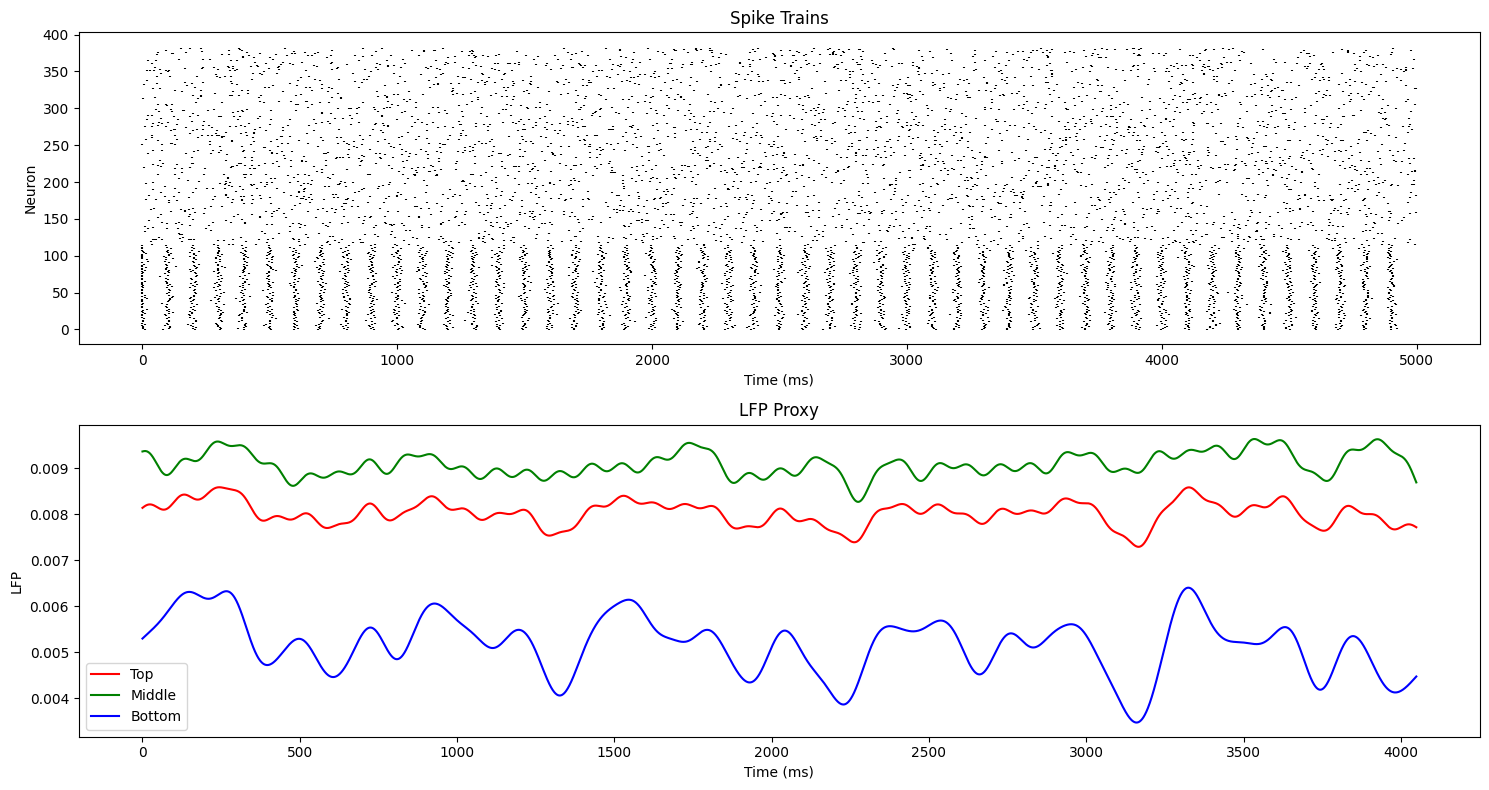

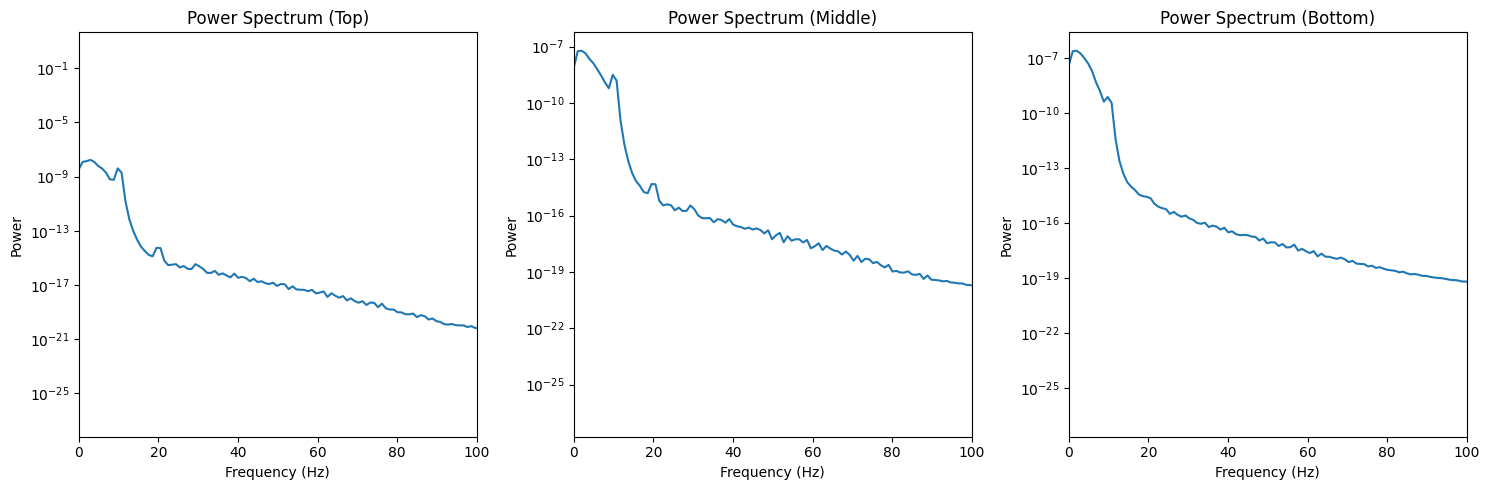

In [42]:

# Visualize spike trains and LFP
def visualize_traces(spike_trains, lfp, num_cols, cut_percent):
    plt.figure(figsize=(15, 8))

    # Plot spike trains
    plt.subplot(2, 1, 1)
    plt.eventplot([np.where(spike_trains[i, :] > 0)[0] for i in range(spike_trains.shape[0])], 
                  linelengths=0.8, colors='black')
    plt.title('Spike Trains')
    plt.xlabel('Time (ms)')
    plt.ylabel('Neuron')

    # Plot LFP
    plt.subplot(2, 1, 2)
    cut_start = int(cut_percent * lfp.shape[2])
    cut_end = int((1 - cut_percent) * lfp.shape[2])
    lfp = lfp[:, :, cut_start:cut_end]
    
    # Visualize three samples from top, middle, and bottom
    lfp_top = np.mean(lfp[0, :, :], axis=0)
    lfp_middle = np.mean(lfp[1, int(num_cols//3):int(2*num_cols//3), :], axis=0)
    lfp_bottom = np.mean(lfp[1, int(2*num_cols//3):, :], axis=0)

    plt.plot(lfp_top, color='red', label='Top')
    plt.plot(lfp_middle, color='green', label='Middle')
    plt.plot(lfp_bottom, color='blue', label='Bottom')
    plt.title('LFP Proxy')
    plt.xlabel('Time (ms)')
    plt.ylabel('LFP')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Compute and plot power spectrum for each channel and then average them
def compute_average_power_spectrum(lfp, fs=1000):
    num_channels = lfp.shape[0]
    Pxx_all = []
    for ch in range(num_channels):
        f, Pxx = welch(lfp[ch, :], fs=fs, nperseg=1024)
        Pxx_all.append(Pxx)
    Pxx_mean = np.mean(Pxx_all, axis=0)
    return f, Pxx_mean

# Main script
spike_trains = generate_spike_trains(num_neurons, num_timepoints, periodic_spike_rate, poisson_spike_rate, periodic_neurons_fraction)
lfp = generate_lfp(spike_trains, gaussian_std, local_gaussian_std, num_rows, num_cols)

# Cut the beginning and end of the LFP signal
cut_start = int(cut_percent * num_timepoints)
cut_end = int((1 - cut_percent) * num_timepoints)
lfp = lfp[:, :, cut_start:cut_end]

# Divide LFP into top, middle, and bottom segments
lfp_top = lfp[:, :num_cols//2, :]
lfp_middle = lfp[:, int(num_cols//3):int(2*num_cols//3), :]
lfp_bottom = lfp[:, num_cols//2:, :]

# Compute power spectra for each segment
fs = 1000 / resolution
f_top, Pxx_top = compute_average_power_spectrum(lfp_top.reshape(-1, lfp_top.shape[2]), fs)
f_middle, Pxx_middle = compute_average_power_spectrum(lfp_middle.reshape(-1, lfp_middle.shape[2]), fs)
f_bottom, Pxx_bottom = compute_average_power_spectrum(lfp_bottom.reshape(-1, lfp_bottom.shape[2]), fs)

# Visualize results
visualize_traces(spike_trains, lfp, num_cols, cut_percent)

plt.figure(figsize=(15, 5))

# Plot power spectrum for top
plt.subplot(1, 3, 1)
plt.semilogy(f_top, Pxx_top)
plt.title('Power Spectrum (Top)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')
plt.xlim([0,100])

# Plot power spectrum for middle
plt.subplot(1, 3, 2)
plt.semilogy(f_middle, Pxx_middle)
plt.title('Power Spectrum (Middle)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')
plt.xlim([0,100])

# Plot power spectrum for bottom
plt.subplot(1, 3, 3)
plt.semilogy(f_bottom, Pxx_bottom)
plt.title('Power Spectrum (Bottom)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')
plt.xlim([0,100])

plt.tight_layout()
plt.show()

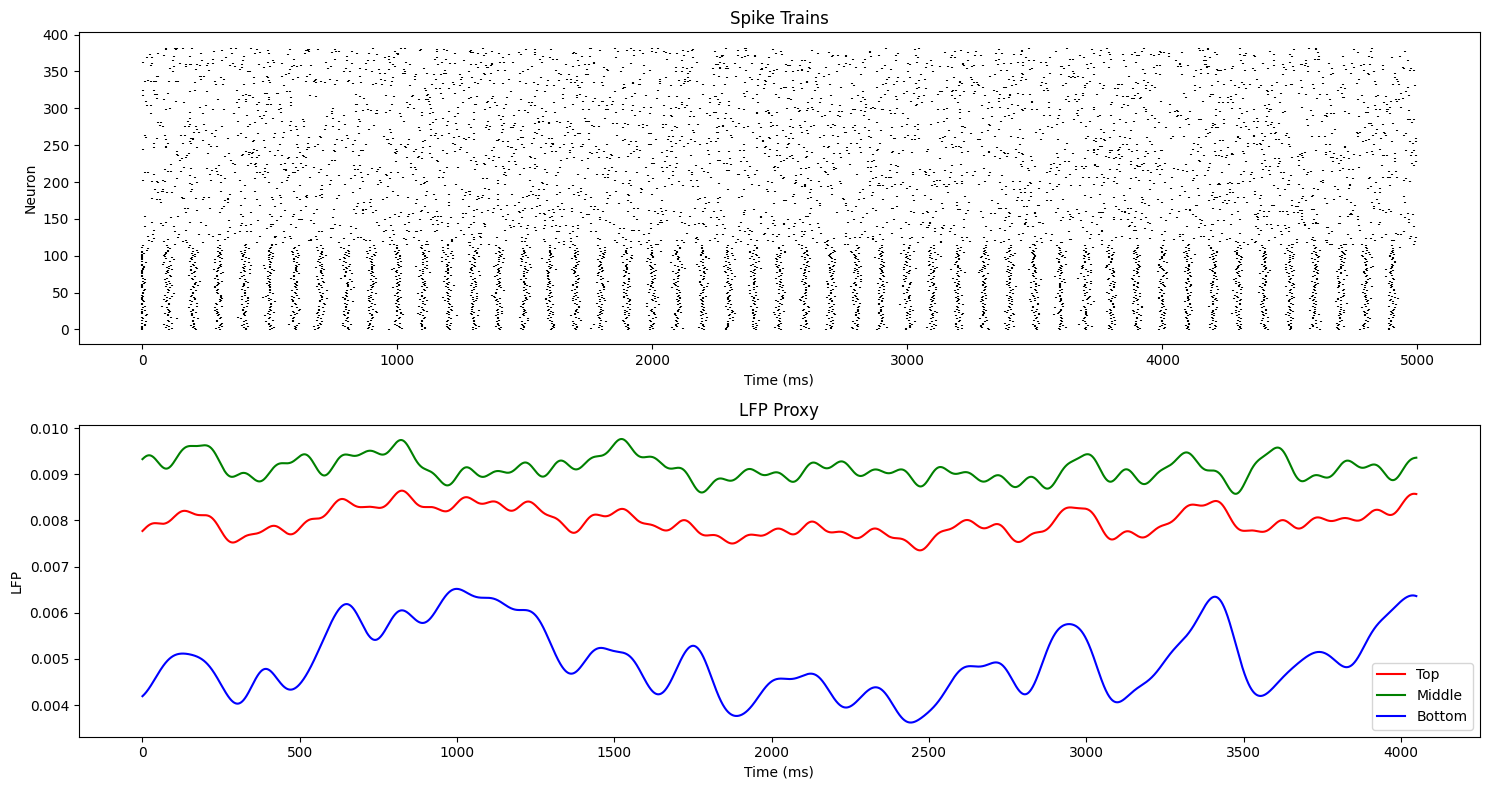

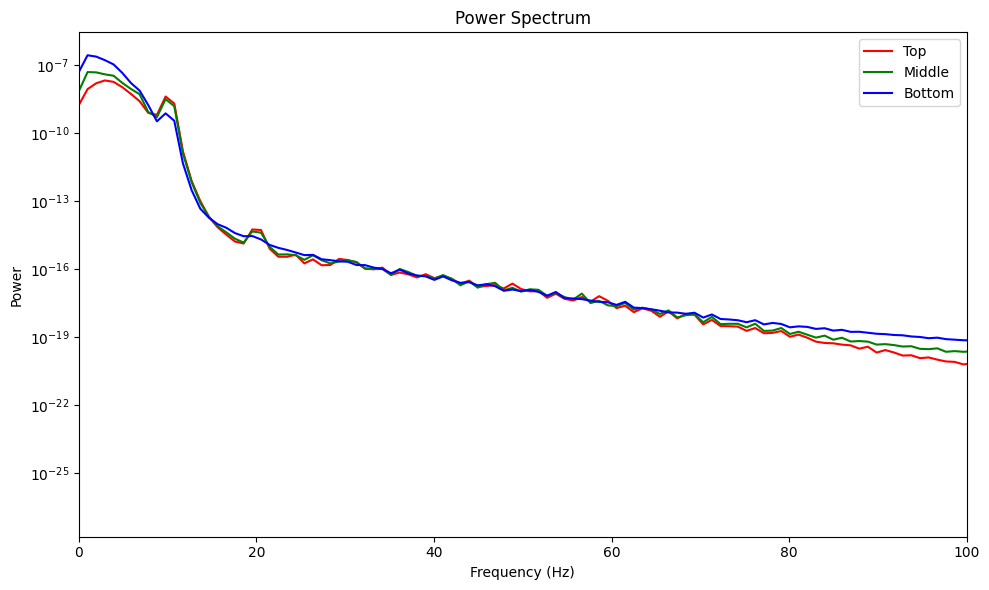

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.signal import welch

# Parameters
num_rows = 2
num_cols = 192
num_neurons = num_rows * num_cols
duration = 5  # seconds
resolution = 1  # ms
num_timepoints = duration * 1000 // resolution
gaussian_std = 5  # Standard deviation of Gaussian kernel for smoothing spikes
local_gaussian_std = 50  # Standard deviation for local Gaussian kernel for LFP
periodic_spike_rate = 10  # Hz
poisson_spike_rate = 5  # Hz
periodic_neurons_fraction = 0.3  # Fraction of neurons with periodic spiking
cut_percent = 0.05  # Cut 5% from the beginning and end

# Generate spike trains
def generate_spike_trains(num_neurons, num_timepoints, periodic_spike_rate, poisson_spike_rate, periodic_neurons_fraction):
    spike_trains = np.zeros((num_neurons, num_timepoints))
    num_periodic_neurons = int(num_neurons * periodic_neurons_fraction)
    num_poisson_neurons = num_neurons - num_periodic_neurons

    # Generate periodic spike trains
    for i in range(num_periodic_neurons):
        spike_times = np.arange(0, num_timepoints, int(1000 / periodic_spike_rate))
        noise = np.random.normal(0, 10, len(spike_times)).astype(int)  # Add some jitter
        spike_times = np.clip(spike_times + noise, 0, num_timepoints - 1)
        spike_trains[i, spike_times] = 1

    # Generate Poisson spike trains
    for i in range(num_periodic_neurons, num_neurons):
        spike_trains[i, :] = np.random.poisson(poisson_spike_rate / 1000, num_timepoints)

    return spike_trains

# Generate LFP proxies using spatio-temporal filtering
def generate_lfp(spike_trains, gaussian_std, local_gaussian_std, num_rows, num_cols):
    lfp = np.zeros((num_rows, num_cols, spike_trains.shape[1]))
    for r in range(num_rows):
        for c in range(num_cols):
            neighbors = get_neighbors(spike_trains, r, c, num_rows, num_cols, num_neighbors=20)
            local_lfp = gaussian_filter1d(neighbors, sigma=gaussian_std)
            lfp[r, c, :] = gaussian_filter1d(local_lfp, sigma=local_gaussian_std)
    return lfp

def get_neighbors(spike_trains, row, col, num_rows, num_cols, num_neighbors=20):
    neighbors = []
    for dr in range(-2, 3):
        for dc in range(-10, 11):
            nr, nc = row + dr, col + dc
            if 0 <= nr < num_rows and 0 <= nc < num_cols:
                neighbors.append(spike_trains[nr * num_cols + nc, :])
    neighbors = np.array(neighbors)
    if neighbors.shape[0] > num_neighbors:
        neighbors = neighbors[:num_neighbors, :]
    return np.mean(neighbors, axis=0)

# Visualize spike trains and LFP
def visualize_traces(spike_trains, lfp, num_cols, cut_percent):
    plt.figure(figsize=(15, 8))

    # Plot spike trains
    plt.subplot(2, 1, 1)
    plt.eventplot([np.where(spike_trains[i, :] > 0)[0] for i in range(spike_trains.shape[0])], 
                  linelengths=0.8, colors='black')
    plt.title('Spike Trains')
    plt.xlabel('Time (ms)')
    plt.ylabel('Neuron')

    # Plot LFP
    plt.subplot(2, 1, 2)
    cut_start = int(cut_percent * lfp.shape[2])
    cut_end = int((1 - cut_percent) * lfp.shape[2])
    lfp = lfp[:, :, cut_start:cut_end]
    
    # Visualize three samples from top, middle, and bottom
    lfp_top = np.mean(lfp[0, :, :], axis=0)
    lfp_middle = np.mean(lfp[1, int(num_cols//3):int(2*num_cols//3), :], axis=0)
    lfp_bottom = np.mean(lfp[1, int(2*num_cols//3):, :], axis=0)

    plt.plot(lfp_top, color='red', label='Top')
    plt.plot(lfp_middle, color='green', label='Middle')
    plt.plot(lfp_bottom, color='blue', label='Bottom')
    plt.title('LFP Proxy')
    plt.xlabel('Time (ms)')
    plt.ylabel('LFP')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Compute and plot power spectrum for each channel and then average them
def compute_average_power_spectrum(lfp, fs=1000):
    num_channels = lfp.shape[0]
    Pxx_all = []
    for ch in range(num_channels):
        f, Pxx = welch(lfp[ch, :], fs=fs, nperseg=1024)
        Pxx_all.append(Pxx)
    Pxx_mean = np.mean(Pxx_all, axis=0)
    return f, Pxx_mean

# Plot power spectrum for top, middle, and bottom segments
def plot_power_spectrum(f_top, Pxx_top, f_middle, Pxx_middle, f_bottom, Pxx_bottom):
    plt.figure(figsize=(10, 6))
    plt.semilogy(f_top, Pxx_top, label='Top', color='red')
    plt.semilogy(f_middle, Pxx_middle, label='Middle', color='green')
    plt.semilogy(f_bottom, Pxx_bottom, label='Bottom', color='blue')
    plt.title('Power Spectrum')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Power')
    plt.legend()
    plt.xlim([0, 100])
    plt.tight_layout()
    plt.show()

# Main script
spike_trains = generate_spike_trains(num_neurons, num_timepoints, periodic_spike_rate, poisson_spike_rate, periodic_neurons_fraction)
lfp = generate_lfp(spike_trains, gaussian_std, local_gaussian_std, num_rows, num_cols)

# Cut the beginning and end of the LFP signal
cut_start = int(cut_percent * num_timepoints)
cut_end = int((1 - cut_percent) * num_timepoints)
lfp = lfp[:, :, cut_start:cut_end]

# Divide LFP into top, middle, and bottom segments
lfp_top = lfp[:, :num_cols//2, :]
lfp_middle = lfp[:, int(num_cols//3):int(2*num_cols//3), :]
lfp_bottom = lfp[:, num_cols//2:, :]

# Compute power spectra for each segment
fs = 1000 / resolution
f_top, Pxx_top = compute_average_power_spectrum(lfp_top.reshape(-1, lfp_top.shape[2]), fs)
f_middle, Pxx_middle = compute_average_power_spectrum(lfp_middle.reshape(-1, lfp_middle.shape[2]), fs)
f_bottom, Pxx_bottom = compute_average_power_spectrum(lfp_bottom.reshape(-1, lfp_bottom.shape[2]), fs)

# Visualize results
visualize_traces(spike_trains, lfp, num_cols, cut_percent)
plot_power_spectrum(f_top, Pxx_top, f_middle, Pxx_middle, f_bottom, Pxx_bottom)


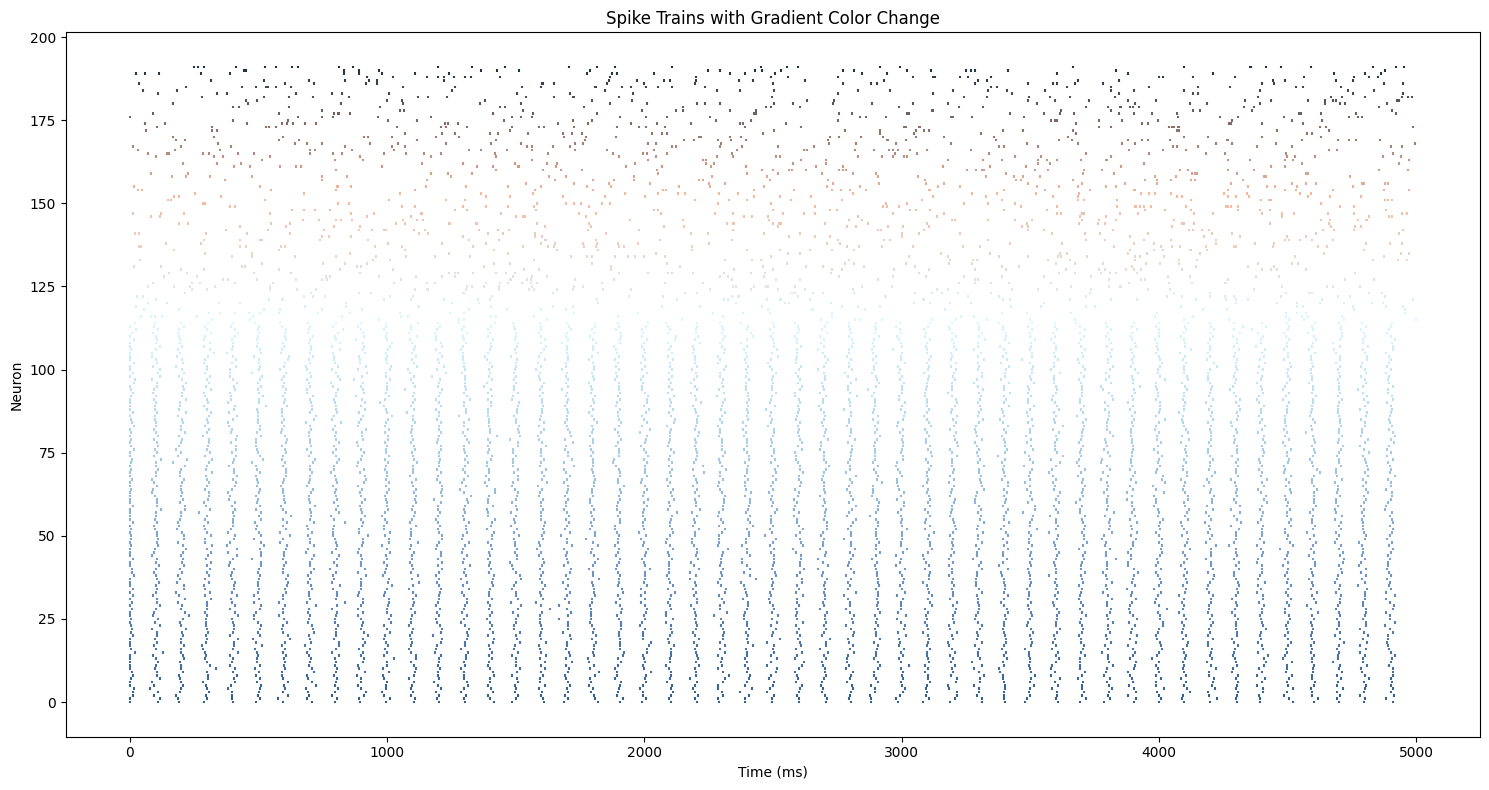

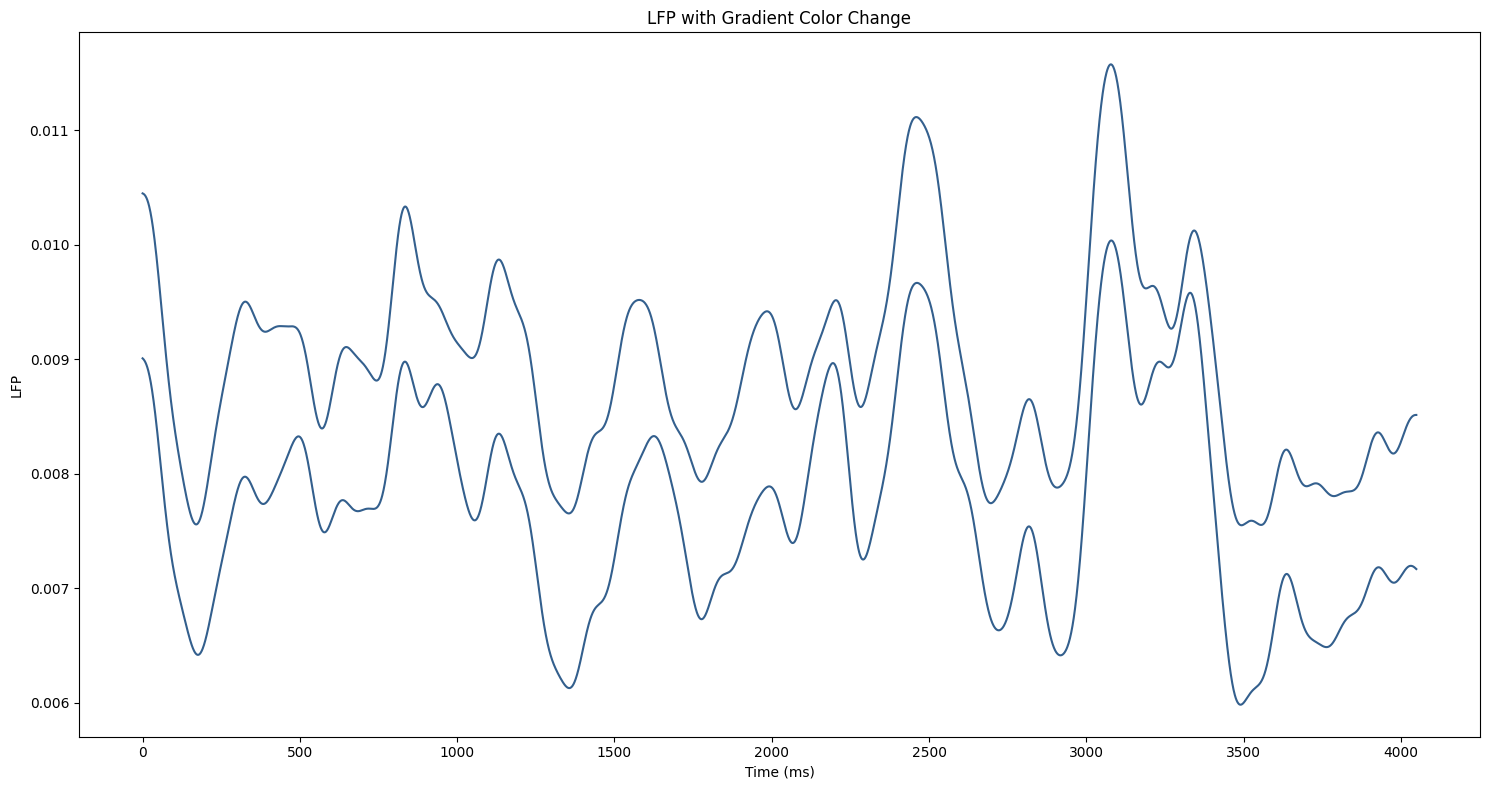

In [56]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Parameters
num_cols = 192  # Number of columns in your data
cut_percent = 0.05  # Percentage of the signal to cut from the beginning and end

# Assume spike_trains and lfp are already generated and provided
# Example data (replace with your actual data)
#spike_trains = np.random.rand(num_cols, 5000) > 0.99  # Example spike trains
#lfp = np.random.rand(2, num_cols, 5000)  # Example LFP data

# Define the specific color palette from the image
palette = ['#335f8d', '#6d94c7', '#a9cfe8', '#d9f7ff', '#f4b89b', '#1e2d3d']
cmap = mcolors.LinearSegmentedColormap.from_list('custom_blue_gradient', palette)
colors = [cmap(i/num_cols) for i in range(num_cols)]

# Plot Spike Trains with Gradient Colors
plt.figure(figsize=(15, 8))
for idx in range(num_cols):
    color = colors[idx]
    spike_times = np.where(spike_trains[idx, :] > 0)[0]
    plt.eventplot(spike_times, lineoffsets=idx, linelengths=0.8, colors=color)
plt.title('Spike Trains with Gradient Color Change')
plt.xlabel('Time (ms)')
plt.ylabel('Neuron')
plt.tight_layout()
plt.show()

# Cut the beginning and end of the LFP signal
cut_start = int(cut_percent * lfp.shape[2])
cut_end = int((1 - cut_percent) * lfp.shape[2])
lfp = lfp[:, :, cut_start:cut_end]

# Plot LFP with Gradient Colors
plt.figure(figsize=(15, 8))
for idx in range(2):
    color = colors[idx]
    plt.plot(lfp[0, idx, :] + idx * 0.001, color=color)
plt.title('LFP with Gradient Color Change')
plt.xlabel('Time (ms)')
plt.ylabel('LFP')
plt.tight_layout()
plt.show()


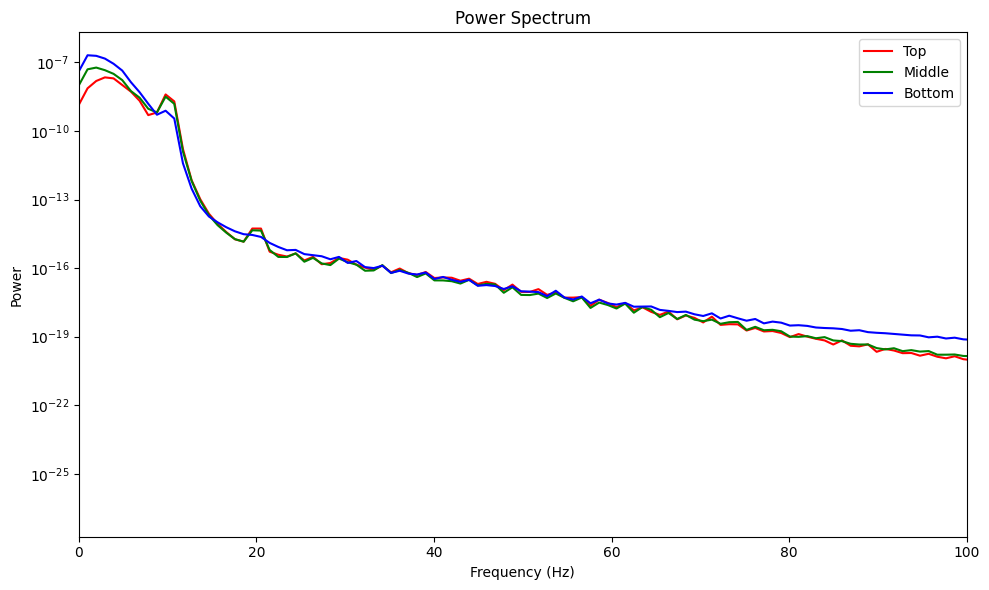

In [57]:
# Main script
spike_trains = generate_spike_trains(num_neurons, num_timepoints, periodic_spike_rate, poisson_spike_rate, periodic_neurons_fraction)
lfp = generate_lfp(spike_trains, gaussian_std, local_gaussian_std, num_rows, num_cols)

# Cut the beginning and end of the LFP signal
cut_start = int(cut_percent * num_timepoints)
cut_end = int((1 - cut_percent) * num_timepoints)
lfp = lfp[:, :, cut_start:cut_end]

# Divide LFP into top, middle, and bottom segments
lfp_top = lfp[:, :num_cols//2, :]
lfp_middle = lfp[:, int(num_cols//3):int(2*num_cols//3), :]
lfp_bottom = lfp[:, num_cols//2:, :]

# Compute power spectra for each segment
fs = 1000 / resolution
f_top, Pxx_top = compute_average_power_spectrum(lfp_top.reshape(-1, lfp_top.shape[2]), fs)
f_middle, Pxx_middle = compute_average_power_spectrum(lfp_middle.reshape(-1, lfp_middle.shape[2]), fs)
f_bottom, Pxx_bottom = compute_average_power_spectrum(lfp_bottom.reshape(-1, lfp_bottom.shape[2]), fs)

plot_power_spectrum(f_top, Pxx_top, f_middle, Pxx_middle, f_bottom, Pxx_bottom)

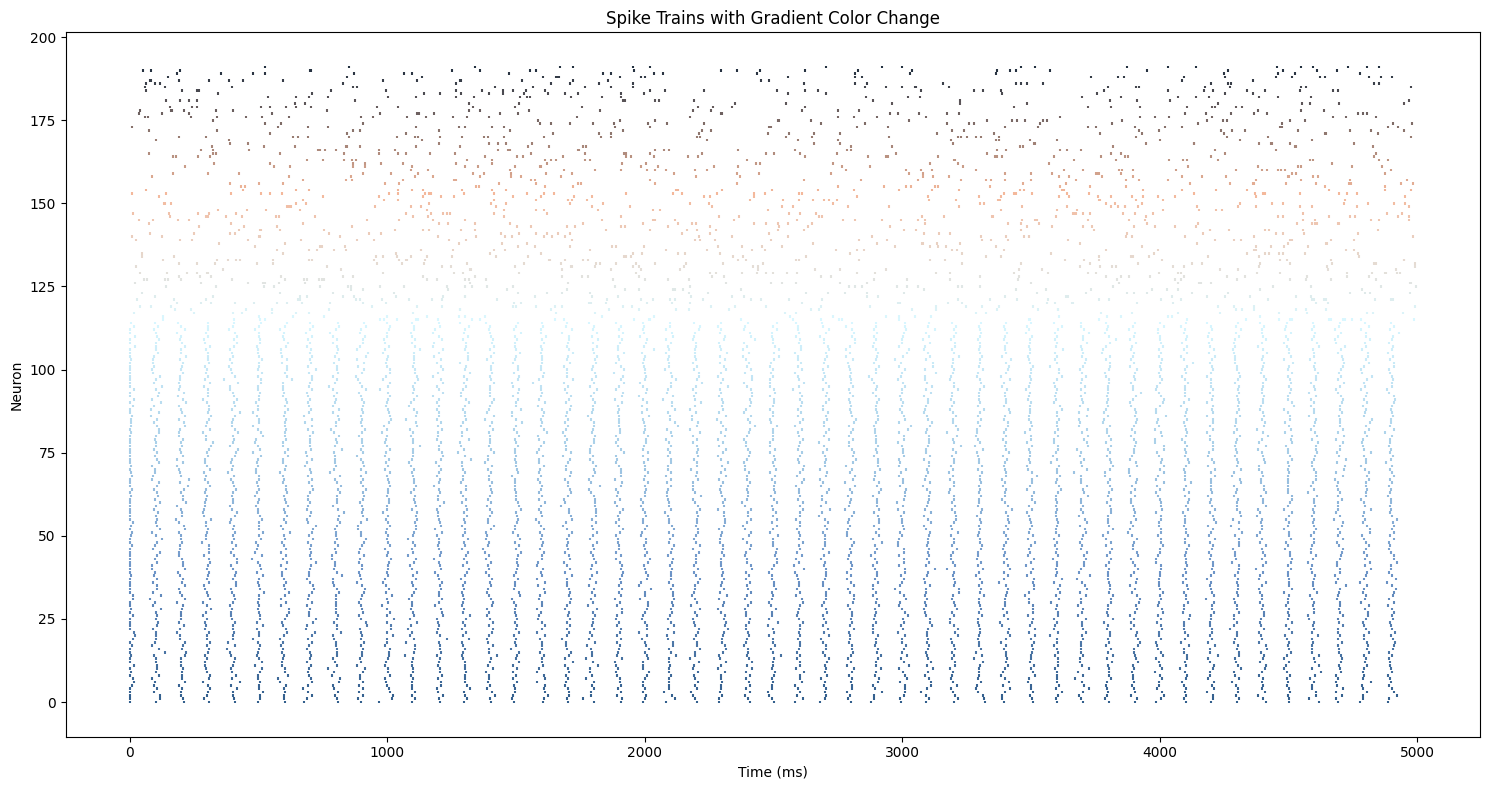

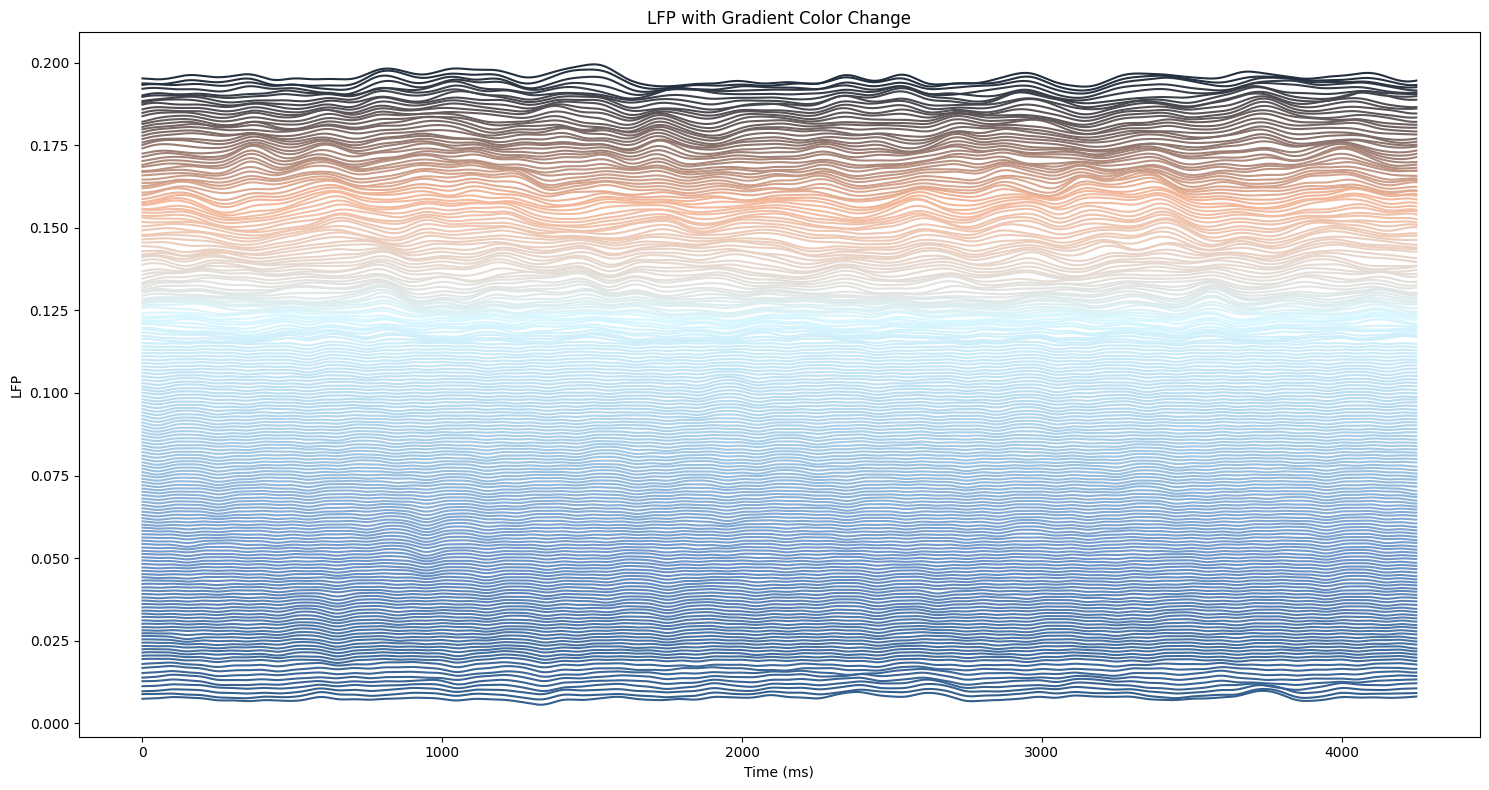

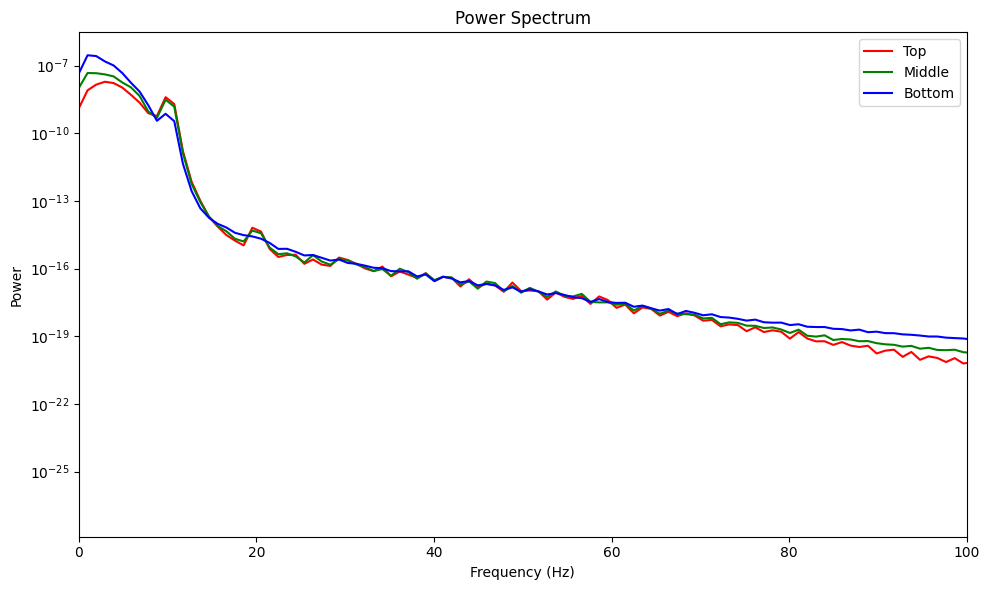

In [59]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.ndimage import gaussian_filter1d
from scipy.signal import welch

# Parameters
num_rows = 2
num_cols = 192
num_neurons = num_rows * num_cols
duration = 5  # seconds
resolution = 1  # ms
num_timepoints = duration * 1000 // resolution
gaussian_std = 5  # Standard deviation of Gaussian kernel for smoothing spikes
local_gaussian_std = 50  # Standard deviation for local Gaussian kernel for LFP
periodic_spike_rate = 10  # Hz
poisson_spike_rate = 5  # Hz
periodic_neurons_fraction = 0.3  # Fraction of neurons with periodic spiking
cut_percent = 0.05  # Cut 5% from the beginning and end

# Generate spike trains
def generate_spike_trains(num_neurons, num_timepoints, periodic_spike_rate, poisson_spike_rate, periodic_neurons_fraction):
    spike_trains = np.zeros((num_neurons, num_timepoints))
    num_periodic_neurons = int(num_neurons * periodic_neurons_fraction)
    num_poisson_neurons = num_neurons - num_periodic_neurons

    # Generate periodic spike trains
    for i in range(num_periodic_neurons):
        spike_times = np.arange(0, num_timepoints, int(1000 / periodic_spike_rate))
        noise = np.random.normal(0, 10, len(spike_times)).astype(int)  # Add some jitter
        spike_times = np.clip(spike_times + noise, 0, num_timepoints - 1)
        spike_trains[i, spike_times] = 1

    # Generate Poisson spike trains
    for i in range(num_periodic_neurons, num_neurons):
        spike_trains[i, :] = np.random.poisson(poisson_spike_rate / 1000, num_timepoints)

    return spike_trains

# Generate LFP proxies using spatio-temporal filtering
def generate_lfp(spike_trains, gaussian_std, local_gaussian_std, num_rows, num_cols):
    lfp = np.zeros((num_rows, num_cols, spike_trains.shape[1]))
    for r in range(num_rows):
        for c in range(num_cols):
            neighbors = get_neighbors(spike_trains, r, c, num_rows, num_cols, num_neighbors=20)
            local_lfp = gaussian_filter1d(neighbors, sigma=gaussian_std)
            lfp[r, c, :] = gaussian_filter1d(local_lfp, sigma=local_gaussian_std)
    return lfp

def get_neighbors(spike_trains, row, col, num_rows, num_cols, num_neighbors=20):
    neighbors = []
    for dr in range(-2, 3):
        for dc in range(-10, 11):
            nr, nc = row + dr, col + dc
            if 0 <= nr < num_rows and 0 <= nc < num_cols:
                neighbors.append(spike_trains[nr * num_cols + nc, :])
    neighbors = np.array(neighbors)
    if neighbors.shape[0] > num_neighbors:
        neighbors = neighbors[:num_neighbors, :]
    return np.mean(neighbors, axis=0)

# Define the specific color palette from the image
palette = ['#335f8d', '#6d94c7', '#a9cfe8', '#d9f7ff', '#f4b89b', '#1e2d3d']
cmap = mcolors.LinearSegmentedColormap.from_list('custom_blue_gradient', palette)
colors = [cmap(i/num_cols) for i in range(num_cols)]

# Plot Spike Trains with Gradient Colors
plt.figure(figsize=(15, 8))
for idx in range(num_cols):
    color = colors[idx]
    spike_times = np.where(spike_trains[idx, :] > 0)[0]
    plt.eventplot(spike_times, lineoffsets=idx, linelengths=0.8, colors=color)
plt.title('Spike Trains with Gradient Color Change')
plt.xlabel('Time (ms)')
plt.ylabel('Neuron')
plt.tight_layout()
plt.show()

# Cut the beginning and end of the LFP signal
cut_start = int(cut_percent * num_timepoints)
cut_end = int((1 - cut_percent) * num_timepoints)
lfp = lfp[:, :, cut_start:cut_end]

# Plot LFP with Gradient Colors
plt.figure(figsize=(15, 8))
for idx in range(num_cols):
    color = colors[idx]
    plt.plot(lfp[0, idx, :] + idx * 0.001, color=color)
plt.title('LFP with Gradient Color Change')
plt.xlabel('Time (ms)')
plt.ylabel('LFP')
plt.tight_layout()
plt.show()

# Divide LFP into top, middle, and bottom segments
lfp_top = lfp[:, :num_cols//2, :]
lfp_middle = lfp[:, int(num_cols//3):int(2*num_cols//3), :]
lfp_bottom = lfp[:, num_cols//2:, :]

# Compute power spectra for each segment
fs = 1000 / resolution
f_top, Pxx_top = compute_average_power_spectrum(lfp_top.reshape(-1, lfp_top.shape[2]), fs)
f_middle, Pxx_middle = compute_average_power_spectrum(lfp_middle.reshape(-1, lfp_middle.shape[2]), fs)
f_bottom, Pxx_bottom = compute_average_power_spectrum(lfp_bottom.reshape(-1, lfp_bottom.shape[2]), fs)

# Plot power spectrum for top, middle, and bottom segments
plt.figure(figsize=(10, 6))
plt.semilogy(f_top, Pxx_top, label='Top', color='red')
plt.semilogy(f_middle, Pxx_middle, label='Middle', color='green')
plt.semilogy(f_bottom, Pxx_bottom, label='Bottom', color='blue')
plt.title('Power Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')
plt.legend()
plt.xlim([0, 100])
plt.tight_layout()
plt.show()


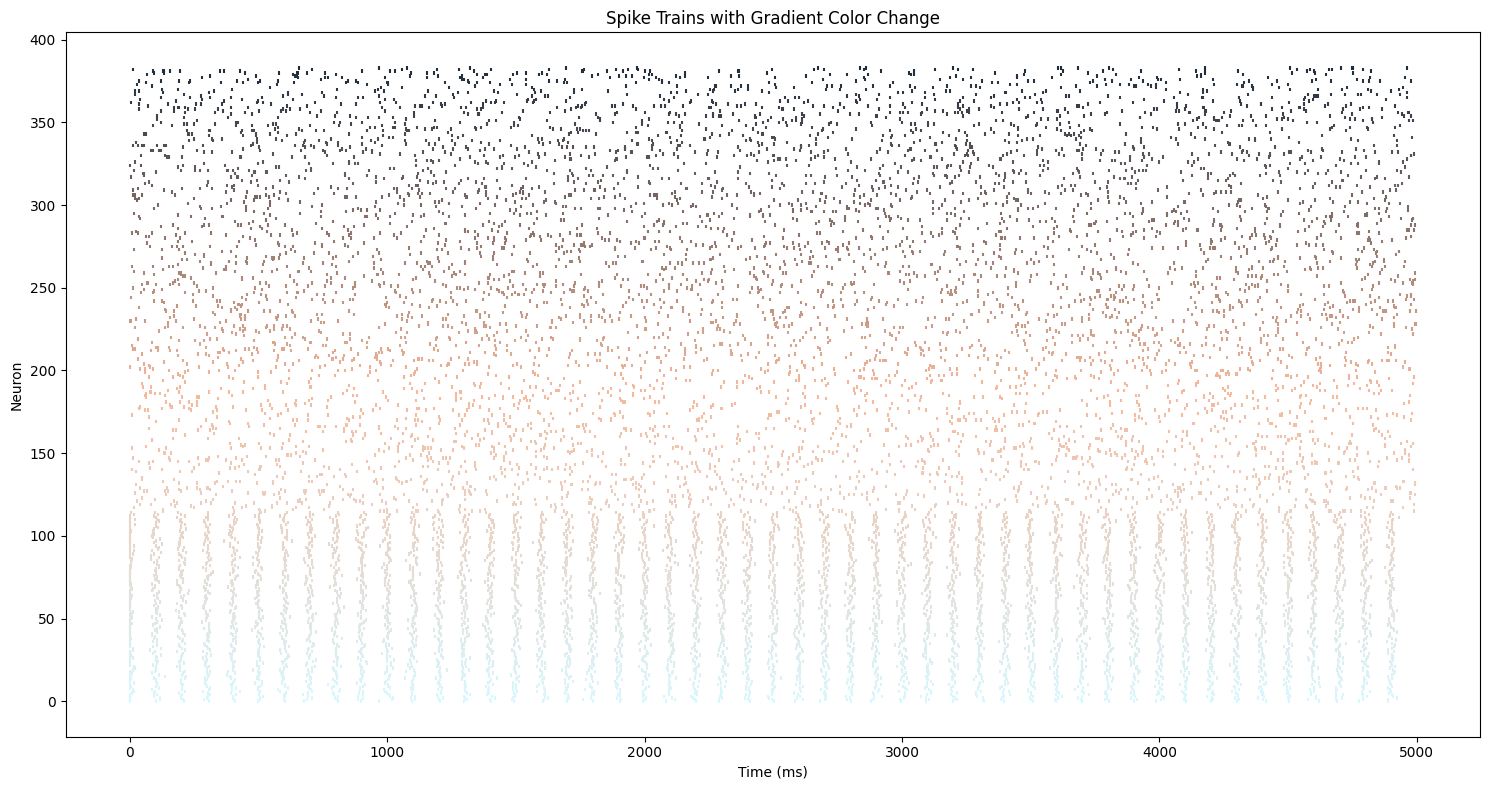

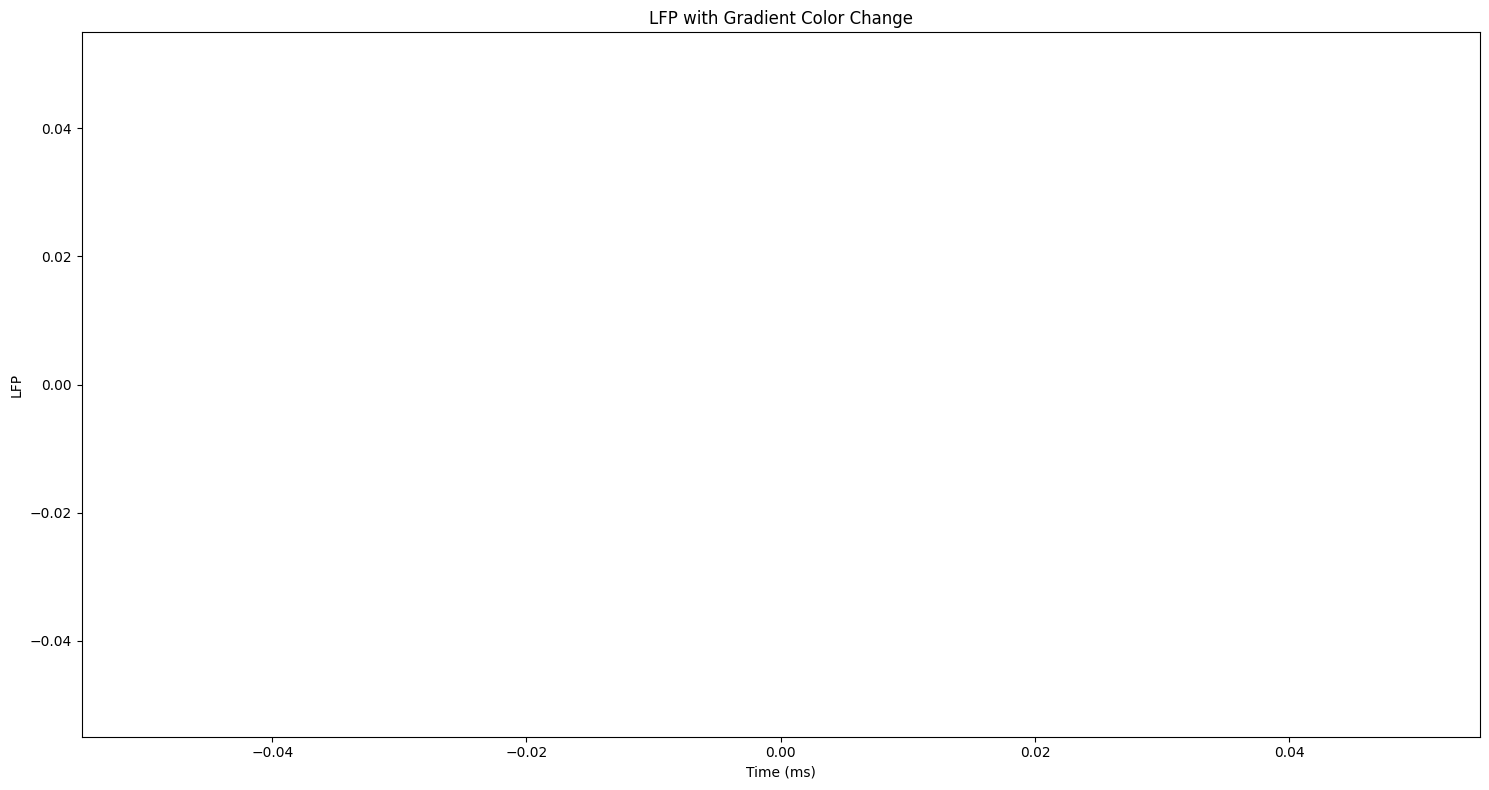

ValueError: cannot reshape array of size 0 into shape (0)

In [79]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.ndimage import gaussian_filter1d
from scipy.signal import welch

# Parameters
num_rows = 2
num_cols = 192
num_neurons = num_rows * num_cols
duration = 5  # seconds
resolution = 1  # ms
num_timepoints = duration * 1000 // resolution
gaussian_std = 5  # Standard deviation of Gaussian kernel for smoothing spikes
local_gaussian_std = 50  # Standard deviation for local Gaussian kernel for LFP
periodic_spike_rate = 10  # Hz
poisson_spike_rate = 5  # Hz
periodic_neurons_fraction = 0.3  # Fraction of neurons with periodic spiking
cut_percent = 0.05  # Cut 5% from the beginning and end

# Generate spike trains
def generate_spike_trains(num_neurons, num_timepoints, periodic_spike_rate, poisson_spike_rate, periodic_neurons_fraction):
    spike_trains = np.zeros((num_neurons, num_timepoints))
    num_periodic_neurons = int(num_neurons * periodic_neurons_fraction)
    num_poisson_neurons = num_neurons - num_periodic_neurons

    # Generate periodic spike trains
    for i in range(num_periodic_neurons):
        spike_times = np.arange(0, num_timepoints, int(1000 / periodic_spike_rate))
        noise = np.random.normal(0, 10, len(spike_times)).astype(int)  # Add some jitter
        spike_times = np.clip(spike_times + noise, 0, num_timepoints - 1)
        spike_trains[i, spike_times] = 1

    # Generate Poisson spike trains
    for i in range(num_periodic_neurons, num_neurons):
        spike_trains[i, :] = np.random.poisson(poisson_spike_rate / 1000, num_timepoints)

    return spike_trains

# Generate LFP proxies using spatio-temporal filtering
def generate_lfp(spike_trains, gaussian_std, local_gaussian_std, num_rows, num_cols):
    lfp = np.zeros((num_rows, num_cols, spike_trains.shape[1]))
    for r in range(num_rows):
        for c in range(num_cols):
            neighbors = get_neighbors(spike_trains, r, c, num_rows, num_cols, num_neighbors=20)
            local_lfp = gaussian_filter1d(neighbors, sigma=gaussian_std)
            lfp[r, c, :] = gaussian_filter1d(local_lfp, sigma=local_gaussian_std)
    return lfp

def get_neighbors(spike_trains, row, col, num_rows, num_cols, num_neighbors=20):
    neighbors = []
    for dr in range(-2, 3):
        for dc in range(-10, 11):
            nr, nc = row + dr, col + dc
            if 0 <= nr < num_rows and 0 <= nc < num_cols:
                neighbors.append(spike_trains[nr * num_cols + nc, :])
    neighbors = np.array(neighbors)
    if neighbors.shape[0] > num_neighbors:
        neighbors = neighbors[:num_neighbors, :]
    return np.mean(neighbors, axis=0)

# Define the specific color palette from the image
#palette = ['#335f8d', '#6d94c7', '#a9cfe8', '#d9f7ff', '#f4b89b', '#1e2d3d']
palette = ['#d9f7ff', '#f4b89b', '#1e2d3d']
cmap = mcolors.LinearSegmentedColormap.from_list('custom_blue_gradient', palette)
colors = [cmap(i/num_neurons) for i in range(num_neurons)]

# Plot Spike Trains with Gradient Colors
plt.figure(figsize=(15, 8))
for idx in range(num_neurons):
    color = colors[idx]
    spike_times = np.where(spike_trains[idx, :] > 0)[0]
    plt.eventplot(spike_times, lineoffsets=idx, linelengths=2.1, colors=color)
plt.title('Spike Trains with Gradient Color Change')
plt.xlabel('Time (ms)')
plt.ylabel('Neuron')
plt.tight_layout()
plt.show()

# Cut the beginning and end of the LFP signal
cut_start = int(cut_percent * num_timepoints)
cut_end = int((1 - cut_percent) * num_timepoints)
lfp = lfp[:, :, cut_start:cut_end]

# Plot LFP with Gradient Colors
plt.figure(figsize=(15, 8))
for idx in range(0, num_cols, num_cols//10):
    color = colors[idx]
    plt.plot(lfp[0, idx, :] + idx * 0.001, color=color)
plt.title('LFP with Gradient Color Change')
plt.xlabel('Time (ms)')
plt.ylabel('LFP')
plt.tight_layout()
plt.show()



# Divide LFP into top, middle, and bottom segments
lfp_top = lfp[:, :num_cols//2, :]
lfp_middle = lfp[:, int(num_cols//3):int(2*num_cols//3), :]
lfp_bottom = lfp[:, num_cols//2:, :]

# Compute power spectra for each segment
fs = 1000 / resolution
f_top, Pxx_top = compute_average_power_spectrum(lfp_top.reshape(-1, lfp_top.shape[2]), fs)
f_middle, Pxx_middle = compute_average_power_spectrum(lfp_middle.reshape(-1, lfp_middle.shape[2]), fs)
f_bottom, Pxx_bottom = compute_average_power_spectrum(lfp_bottom.reshape(-1, lfp_bottom.shape[2]), fs)

# Plot power spectrum for top, middle, and bottom segments
plt.figure(figsize=(10, 6))
plt.semilogy(f_top, Pxx_top, label='Top', color='red')
plt.semilogy(f_middle, Pxx_middle, label='Middle', color='green')
plt.semilogy(f_bottom, Pxx_bottom, label='Bottom', color='blue')
plt.title('Power Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')
plt.legend()
plt.xlim([0, 100])
plt.tight_layout()
plt.show()
